# HW4: Recurrent Neural Networks
## Environment Setup and Initial Configurations

Importing standard libraries for tensor operations, data handling, reproducibility controls, and visualization. Device is configured to leverage GPU if available.

In [9]:
import os
import re
import random
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
import matplotlib.pyplot as plt
from collections import Counter

# Reproducibility setup
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Section 2: Implementation Questions
### Sub-section 1: Text Preprocessing & Vocabulary Preparation

#### 1 & 2. Rule-Based Tokenizer and Vocabulary Building
Implementing a basic whitespace tokenizer that lowercases all text and filters out non-alphanumeric characters. The `Vocabulary` class processes the tokenized text to build a frequency dictionary from the training set, retaining the top 5000 most frequent tokens. Indices `0` and `1` are reserved exclusively for `<pad>` and `<unk>` tokens.

In [10]:
def whitespace_tokenizer(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.split()

class Vocabulary:
    def __init__(self, max_size=5000):
        self.max_size = max_size
        self.word2idx = {'<pad>': 0, '<unk>': 1}
        self.idx2word = {0: '<pad>', 1: '<unk>'}
        self.freqs = Counter()

    def build_vocab(self, data):
        for sentence in data:
            self.freqs.update(sentence)
        common_words = self.freqs.most_common(self.max_size)
        for word, _ in common_words:
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def encode(self, tokenized_text):
        return [self.word2idx.get(w, self.word2idx['<unk>']) for w in tokenized_text]

#### 3. Data Loading, Balanced Splitting, and Sequence Statistics
Loading the positive and negative movie review dataset using `latin-1` encoding. The samples are split using seed 42 into balanced splits: 8530 for training, 1066 for validation, and 1066 for testing. Sentence length statistics (mean and standard deviation) are extracted across all splits to verify structural consistency.

In [11]:
def load_and_split_data(data_dir='data'):
    def read_file(filepath):
        with open(filepath, 'r', encoding='latin-1') as f:
            return [line.strip() for line in f if line.strip()]

    pos_lines = read_file(os.path.join(data_dir, 'rt-polarity.pos'))
    neg_lines = read_file(os.path.join(data_dir, 'rt-polarity.neg'))

    pos_data = [(whitespace_tokenizer(line), 1) for line in pos_lines]
    neg_data = [(whitespace_tokenizer(line), 0) for line in neg_lines]

    random.shuffle(pos_data)
    random.shuffle(neg_data)

    # Balanced split: 8530 train, 1066 val, 1066 test
    train_data = pos_data[:4265] + neg_data[:4265]
    val_data = pos_data[4265:4265+533] + neg_data[4265:4265+533]
    test_data = pos_data[4798:4798+533] + neg_data[4798:4798+533]

    random.shuffle(train_data)
    random.shuffle(val_data)
    random.shuffle(test_data)

    return train_data, val_data, test_data

train_raw, val_raw, test_raw = load_and_split_data()

vocab = Vocabulary(max_size=5000)
vocab.build_vocab([item[0] for item in train_raw])

print(f"Train size: {len(train_raw)}, Val size: {len(val_raw)}, Test size: {len(test_raw)}")
print(f"Vocab size: {len(vocab.word2idx)}\n")

# Calculate Mean and Std of sentence lengths for the report
for name, dataset in [("Train", train_raw), ("Val", val_raw), ("Test", test_raw)]:
    lengths = [len(item[0]) for item in dataset]
    print(f"{name} Split -> Mean Length: {np.mean(lengths):.2f}, Std Length: {np.std(lengths):.2f}")

Train size: 8530, Val size: 1066, Test size: 1066
Vocab size: 5002

Train Split -> Mean Length: 18.51, Std Length: 8.57
Val Split -> Mean Length: 18.43, Std Length: 8.74
Test Split -> Mean Length: 18.49, Std Length: 8.57


### Sub-section 2: Model Architecture & Data Loading
#### 1. Custom Collate Function and Dynamic Padding

Defining the PyTorch `Dataset` pipeline alongside a custom `collate_fn`. To utilize `pack_padded_sequence` effectively, batches are sorted by sentence length in descending order. Padding is applied dynamically to match only the maximum length of the current batch rather than the global maximum length, reducing memory footprint and redundant operations.

In [12]:
class TextDataset(Dataset):
    def __init__(self, data, vocab):
        self.data = [(torch.tensor(vocab.encode(seq), dtype=torch.long), label) for seq, label in data]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

def custom_collate_fn(batch):
    # Sort by length descending for pack_padded_sequence
    batch.sort(key=lambda x: len(x[0]), reverse=True)
    sequences, labels = zip(*batch)
    
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=0)
    labels = torch.tensor(labels, dtype=torch.float)
    
    return padded_seqs, labels, lengths

BATCH_SIZE = 64
train_loader = DataLoader(TextDataset(train_raw, vocab), batch_size=BATCH_SIZE, shuffle=True, collate_fn=custom_collate_fn)
val_loader = DataLoader(TextDataset(val_raw, vocab), batch_size=BATCH_SIZE, collate_fn=custom_collate_fn)
test_loader = DataLoader(TextDataset(test_raw, vocab), batch_size=BATCH_SIZE, collate_fn=custom_collate_fn)

#### 2. Recurrent Network Architectures (Vanilla RNN, LSTM, GRU)
Implementing a unified model framework wrapping `nn.RNN`, `nn.LSTM`, and `nn.GRU` layers. The embedding dimension is fixed at $D=64$ and the hidden size at $H=128$. The forward pass converts sequences into a `PackedSequence` object to prevent gradient calculations over padded zero tokens, extracting the hidden state corresponding to the last real token for final classification.

In [13]:
class RNNBasedModel(nn.Module):
    def __init__(self, model_type, vocab_size, embed_dim=64, hidden_dim=128, output_dim=1, pad_idx=0):
        super(RNNBasedModel, self).__init__()
        self.model_type = model_type
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        
        if model_type == 'RNN':
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        elif model_type == 'LSTM':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        elif model_type == 'GRU':
            self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
            
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text, text_lengths):
        embedded = self.embedding(text)
        
        # Packing sequences to skip padding tokens during processing
        packed_embedded = pack_padded_sequence(embedded, text_lengths.cpu(), batch_first=True, enforce_sorted=True)
        
        if self.model_type == 'LSTM':
            packed_output, (hidden, cell) = self.rnn(packed_embedded)
        else:
            packed_output, hidden = self.rnn(packed_embedded)
            
        # hidden[-1] correctly extracts the hidden state of the last real token
        return self.fc(hidden[-1])

### Sub-section 3: Training and Performance Evaluation
#### Helper Utilities for Training and Metrics Extraction

Defining standard utility functions to count trainable parameters, compute binary accuracy via logit thresholding, and manage training/evaluation tracking loops over the DataLoader batches.

In [14]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def binary_accuracy(preds, y):
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()
    return correct.sum() / len(correct)

def train_epoch(model, iterator, optimizer, criterion):
    model.train()
    epoch_loss, epoch_acc = 0, 0
    
    for text, labels, lengths in iterator:
        text, labels = text.to(device), labels.to(device)
        optimizer.zero_grad()
        predictions = model(text, lengths).squeeze(1)
        loss = criterion(predictions, labels)
        acc = binary_accuracy(predictions, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_acc += acc.item()
        
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss, epoch_acc = 0, 0
    
    with torch.no_grad():
        for text, labels, lengths in iterator:
            text, labels = text.to(device), labels.to(device)
            predictions = model(text, lengths).squeeze(1)
            loss = criterion(predictions, labels)
            acc = binary_accuracy(predictions, labels)
            
            epoch_loss += loss.item()
            epoch_acc += acc.item()
            
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

#### Training Pipeline and Learning Curves Generation
Training all three recurrent architectures for 5 epochs using the Adam optimizer and `BCEWithLogitsLoss`. Performance statistics are collected to evaluate execution speed and convergence behavior. Training and validation loss/accuracy trends are visualized in side-by-side subplots.

Training RNN model...
Training LSTM model...
Training GRU model...


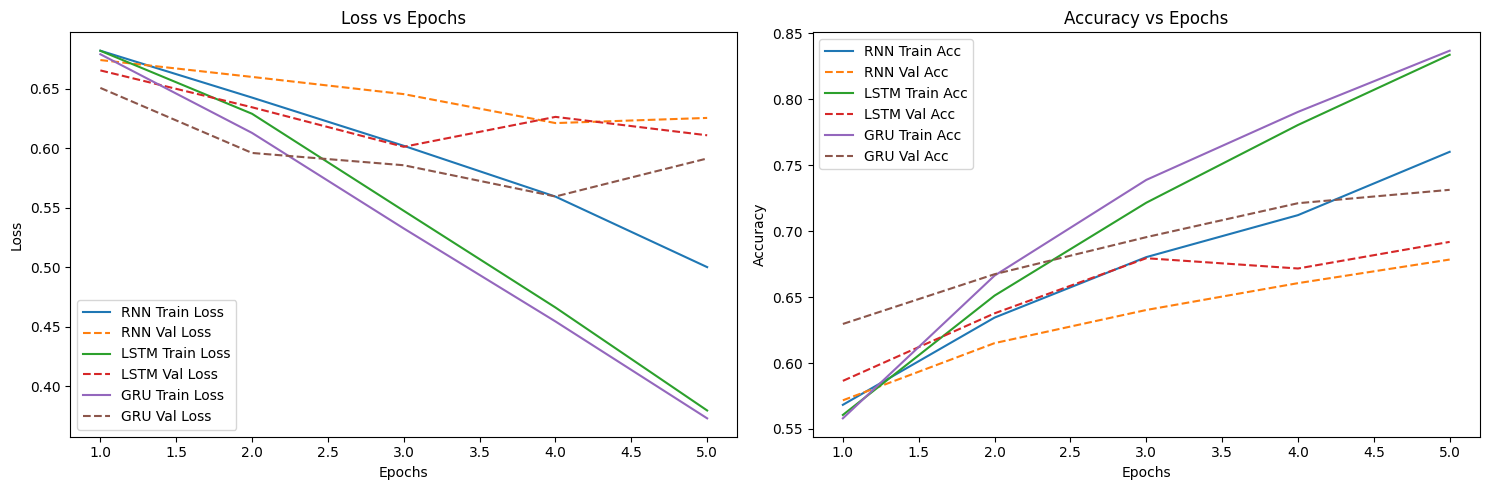


--- Summary Statistics ---
Model: RNN | Params: 345089 | Time: 9.68s | Val Acc: 0.6785 | Test Acc: 0.6535
Model: LSTM | Params: 419585 | Time: 27.35s | Val Acc: 0.6919 | Test Acc: 0.7015
Model: GRU | Params: 394753 | Time: 27.57s | Val Acc: 0.7314 | Test Acc: 0.7223


In [15]:
models_dict = {
    'RNN': RNNBasedModel('RNN', len(vocab.word2idx)).to(device),
    'LSTM': RNNBasedModel('LSTM', len(vocab.word2idx)).to(device),
    'GRU': RNNBasedModel('GRU', len(vocab.word2idx)).to(device)
}

results = {m: {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'time': 0, 'params': 0} for m in models_dict}
criterion = nn.BCEWithLogitsLoss().to(device)
EPOCHS = 5

for name, model in models_dict.items():
    optimizer = optim.Adam(model.parameters())
    results[name]['params'] = count_parameters(model)
    
    print(f"Training {name} model...")
    start_time = time.time()
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        
        results[name]['train_loss'].append(train_loss)
        results[name]['val_loss'].append(val_loss)
        results[name]['train_acc'].append(train_acc)
        results[name]['val_acc'].append(val_acc)
    
    results[name]['time'] = time.time() - start_time
    _, test_acc = evaluate(model, test_loader, criterion)
    results[name]['test_acc'] = test_acc

# Plotting curves (1x2 subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
epochs_range = range(1, EPOCHS + 1)

for name in results:
    ax1.plot(epochs_range, results[name]['train_loss'], label=f'{name} Train Loss')
    ax1.plot(epochs_range, results[name]['val_loss'], linestyle='--', label=f'{name} Val Loss')
    
    ax2.plot(epochs_range, results[name]['train_acc'], label=f'{name} Train Acc')
    ax2.plot(epochs_range, results[name]['val_acc'], linestyle='--', label=f'{name} Val Acc')

ax1.set_title('Loss vs Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.set_title('Accuracy vs Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n--- Summary Statistics ---")
for name in results:
    print(f"Model: {name} | Params: {results[name]['params']} | Time: {results[name]['time']:.2f}s | Val Acc: {results[name]['val_acc'][-1]:.4f} | Test Acc: {results[name]['test_acc']:.4f}")

### Sub-section 4: Gradient Diagnostics & Backpropagation Through Time (BPTT)
#### 1 & 2. Empirical Gradient Flow Analysis

Isolating a subset of 32 validation samples with a sequence length of at least 30 tokens, truncated strictly to $T=30$. The embedding outputs are cloned with explicit gradient tracking enabled (`requires_grad=True`) to isolate the exact gradient flow ($\partial L / \partial e_t$) via `.backward()`. Mean L2 norms across time steps and empirical gradient ratios ($g_1/g_{30}$) are tracked to visualize vanishing behaviors.

--- Empirical Gradient Ratios (g1 / g30) ---
RNN Ratio (g1/g30): 5.023424e-02
LSTM Ratio (g1/g30): 2.269581e-01


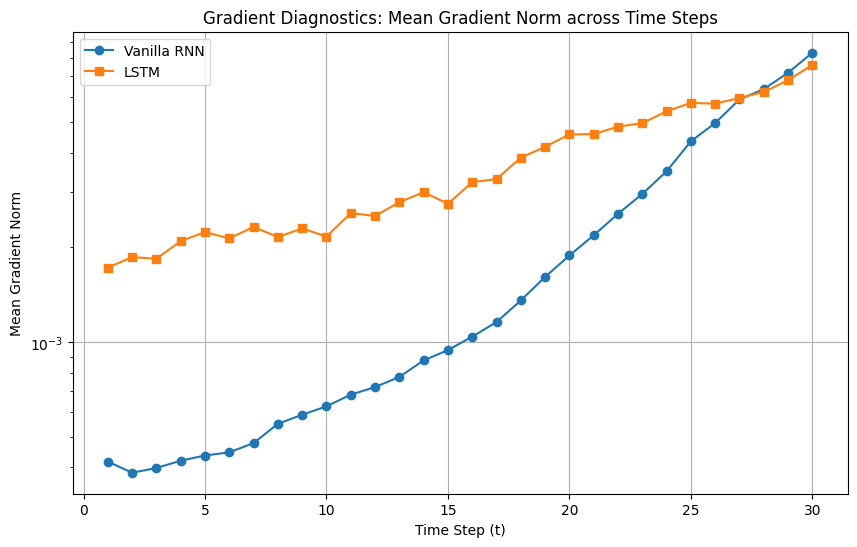

In [16]:
# Filter validation samples with length >= 30 and take exactly 32
long_seqs = [item for item in val_raw if len(item[0]) >= 30][:32]

# Truncate strictly to T=30 tokens
truncated_seqs = [(seq[:30], label) for seq, label in long_seqs]

diag_loader = DataLoader(TextDataset(truncated_seqs, vocab), batch_size=32, collate_fn=custom_collate_fn)
texts, labels, lengths = next(iter(diag_loader))
texts, labels = texts.to(device), labels.to(device)

grad_norms = {'RNN': [], 'LSTM': []}

for name in ['RNN', 'LSTM']:
    model = models_dict[name]
    model.eval()
    
    # Clone and prepare embedding layer for explicit gradient capture
    embedded = model.embedding(texts).clone().detach().requires_grad_(True)
    packed_embedded = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=True)
    
    if name == 'LSTM':
        _, (hidden, _) = model.rnn(packed_embedded)
    else:
        _, hidden = model.rnn(packed_embedded)
        
    predictions = model.fc(hidden[-1]).squeeze(1)
    loss = criterion(predictions, labels)
    
    model.zero_grad()
    loss.backward()
    
    grads = embedded.grad  # Shape: [batch_size, 30, embed_dim]
    
    # Calculate mean L2 norm for each time step t
    for t in range(30):
        step_grads = grads[:, t, :]
        norm = torch.norm(step_grads, p=2, dim=1).mean().item()
        grad_norms[name].append(norm)

# Print empirical gradient ratios (g1/g30) for the report
print("--- Empirical Gradient Ratios (g1 / g30) ---")
for name in ['RNN', 'LSTM']:
    g1 = grad_norms[name][0]
    g30 = grad_norms[name][-1]
    print(f"{name} Ratio (g1/g30): {g1/g30:.6e}")

# Plot and save diagnostic image
plt.figure(figsize=(10, 6))
time_steps = range(1, 31)

plt.plot(time_steps, grad_norms['RNN'], label='Vanilla RNN', marker='o')
plt.plot(time_steps, grad_norms['LSTM'], label='LSTM', marker='s')

plt.title('Gradient Diagnostics: Mean Gradient Norm across Time Steps')
plt.xlabel('Time Step (t)')
plt.ylabel('Mean Gradient Norm')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.savefig('gradient_diagnostics.png')
plt.show()